In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,classification_report, confusion_matrix
import emlearn

- Indlæs data fra csv-fil og fjern problematiske datapunkter
- Konverterer 8bit samples til normaliserede float værdier
- Genererer et "map" over de individuelle lydoptagelser og deres "action"
- Splitter datasættet i test og træningssæt (stratification sørger for ens fordeling af "actions" i de to sæt)
- Opretter separate dataFrames for test og træningssættet baseret på fil-opdelingen

In [2]:
audio_df = pd.read_csv('./samlet2.csv', on_bad_lines='skip')
df = audio_df[audio_df['timestamp'] != 0].copy()

df['sample_float'] = (df['samplevalue'].astype(np.int16) - 128).astype(np.float32) / 128.0

files = df['file'].unique()
file_action_map = df.groupby('file')['action'].first()
actions = file_action_map.loc[files].values

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    stratify=actions,
    random_state=42
)

df_test = df[df['file'].isin(test_files)]
df_train = df[df['file'].isin(train_files)]

Funktion med en række statistiske features

In [3]:
def extract_features(x):
    features = {}
    
    # Basis statistik
    features['x_mean'] = x.mean()
    features['x_std'] = x.std()
    features['x_aad'] = np.mean(np.absolute(x - np.mean(x)))
    features['x_max'] = x.max()
    features['x_min'] = x.min()
    features['x_maxmin_diff'] = x.max() - x.min()
    features['x_median'] = np.median(x)
    features['x_mad'] = np.median(np.absolute(x - np.median(x)))
    features['x_IQR'] = np.percentile(x, 75) - np.percentile(x, 25)
    
    # Tællinger
    features['x_neg_count'] = np.sum(x < 0)
    features['x_pos_count'] = np.sum(x > 0)
    features['x_above_mean'] = np.sum(x > x.mean())
    features['x_peak_count'] = len(find_peaks(x)[0])
    
    # Højere ordens statistik
    features['x_skewness'] = stats.skew(x)
    features['x_kurtosis'] = stats.kurtosis(x)
    features['x_energy'] = np.sum(x**2) / 100
    
    # Positionsbaserede features
    features['x_argmax'] = np.argmax(x)
    features['x_argmin'] = np.argmin(x)
    features['x_arg_diff'] = abs(features['x_argmax'] - features['x_argmin'])
    
    return features

- Klipper optagelser til fast længde og downsampler
- Konverterer hvet lydfil-segment til numeriske features
- Lægger action kolonnen i y_list og encoder y_enc til numeriske værdier
- Stacker samples i et 3D array
- Bruger funktionen til at bygge test og træningssættet
- Opretter label mapping

In [4]:
TARGET_LEN = 15800
DOWNSAMPLE_FACTOR = 2

def build_feature_dataset(df_subset, label_encoder):
    feature_list = []
    y_list = []

    for file_id, g in df_subset.groupby('file', sort=False):
        x = g['sample_float'].values
        x = x[:TARGET_LEN]
        x = x[::DOWNSAMPLE_FACTOR]  # Downsample til 7900 samples
        
        # Udtræk features
        features = extract_features(x)
        feature_list.append(features)
        
        y = g['action'].iloc[0]
        y_list.append(y)
    
    # Konverter til DataFrame og derefter numpy array
    X_df = pd.DataFrame(feature_list)
    X = X_df.values

    y_enc = label_encoder.transform(y_list)
    
    return X, y_enc, X_df.columns.tolist()

# Byg feature-baserede datasæt
le = LabelEncoder().fit(df_train['action'])
X_train, y_train, feature_names = build_feature_dataset(df_train, le)
X_test, y_test, _ = build_feature_dataset(df_test, le)

# Label mapping
label_mapping = {i: cls for i, cls in enumerate(le.classes_)}
print(f"Label mapping: {label_mapping}\n")
print(f"Antal features: {len(feature_names)}")

Label mapping: {0: 'knock', 1: 'noise'}

Antal features: 19


- Scaleren giver alle features mean = 0 og std = 1 (normalisering)
- Samme scaler bruges til begge sæt!
- Der konverteres tilbage til dataframes med feature-navne som koloner

In [5]:
# Normaliser features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konverter til DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print(X_test_scaled)

      x_mean     x_std     x_aad     x_max     x_min  x_maxmin_diff  x_median  \
0   0.250618 -0.325829 -0.417412  0.410974 -0.045179       0.230090       0.0   
1   0.177988  0.100882  0.435887 -0.322481  0.261118      -0.298576       0.0   
2   0.164997 -0.352394 -0.302580 -0.131145  0.567414      -0.362657       0.0   
3   0.061662 -0.141404  0.044521  0.219638  0.107969       0.053868       0.0   
4   0.433079 -0.919930 -1.040597 -1.183494  1.333155      -1.291829       0.0   
5   0.352182 -1.029722 -1.108607 -1.661835  1.547563      -1.644273       0.0   
6   0.335058 -1.024714 -1.096783 -1.502388  1.516933      -1.548152       0.0   
7   0.278371 -0.795364 -0.874741 -0.609486  1.271896      -0.971425       0.0   
8   0.124844 -0.990016 -1.007184 -2.044507  1.608822      -1.868556       0.0   
9   0.283685  0.048876 -0.129231  0.347196 -0.780290       0.582534       0.0   
10  0.308486 -0.868429 -0.776226 -1.438609  1.823229      -1.676314       0.0   
11  0.238218 -0.924851 -1.04

- RFC trænes med train-datasættet
- Modellen testes med test-sættet
- Resultatet vises i en confusion matrice

Accuracy: 0.9

 -------------Klassifikations rapport-------------

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



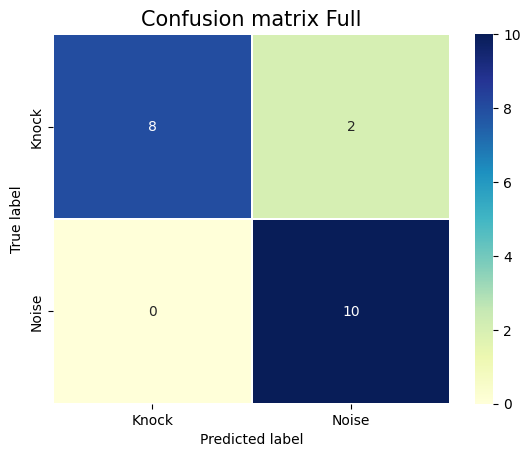

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state = 21)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Klassifikations rapport-------------\n")
print(classification_report(y_test, y_pred))

labels = ['Knock', 'Noise']
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    xticklabels=labels, 
    yticklabels=labels, 
    annot=True,
    linewidths = 0.1, 
    fmt="d", 
    cmap = 'YlGnBu')

plt.title("Confusion matrix Full", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

- Henter den "importance score" RFC genererer
- Opretter en dataframe med featurenavne og deres score

In [7]:
feature_importances = pd.DataFrame(
    rf.feature_importances_,
    index = X_train_scaled.columns,
    columns=['importance']).sort_values('importance', ascending=False)

feature_importances 

,importance
x_argmin,0.148042
x_argmax,0.129943
x_kurtosis,0.105013
x_peak_count,0.062734
x_arg_diff,0.059515
x_aad,0.056313
x_std,0.055487
x_min,0.054743
x_energy,0.047971
x_max,0.046827


Her er der manuelt søgt de mest betydende features. Det er interessant nok forskelligt fra dem ovenstående liste.

In [8]:
top_features = feature_importances.index[[8,11,15,1]]
X_train_sel = X_train_scaled[top_features]
X_test_sel = X_test_scaled[top_features]

rf2 = RandomForestClassifier(random_state=21, n_estimators=100)
rf2.fit(X_train_sel, y_train)
y_pred = rf2.predict(X_test_sel)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Accuracy:", f1_score(y_test, y_pred, average='macro'))
print("Features: ", top_features)

Accuracy: 0.95
Accuracy: 0.949874686716792
Features:  Index(['x_energy', 'x_pos_count', 'x_above_mean', 'x_argmax'], dtype='object')


Accuracy: 0.95

 -------------Classification Report-------------

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



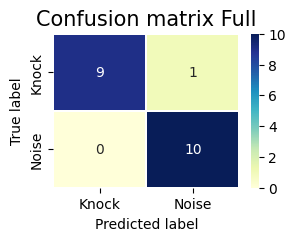

In [9]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

labels = ['Knock', 'Noise']
cm2 = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (3,2))
sns.heatmap(
    cm2, 
    xticklabels=labels, 
    yticklabels=labels, 
    annot=True,
    linewidths = 0.1, 
    fmt="d", 
    cmap = 'YlGnBu')

plt.title("Confusion matrix Full", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Manuel test af mindst mulige estimatorer med 95%

In [10]:
# Test manuelt med færre estimators
for n_est in [9, 10, 20, 50, 100]:
    rf_test = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42)
    rf_test.fit(X_train_sel, y_train)
    y_pred_test = rf_test.predict(X_test_sel)
    print(f"n_estimators={n_est}: Acc={accuracy_score(y_test, y_pred_test):.3f}")

n_estimators=9: Acc=0.950
n_estimators=10: Acc=0.900
n_estimators=20: Acc=0.800
n_estimators=50: Acc=0.900
n_estimators=100: Acc=0.950


In [11]:
# Final model
rf_final = RandomForestClassifier(n_estimators=9, random_state=42)
rf_final.fit(X_train_sel, y_train)

,n_estimators,9
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Genererer headerfil til feature scaling

In [12]:
features_idx = []

for i, feat in enumerate(top_features):
    orig_idx = feature_names.index(feat)
    features_idx.append(orig_idx)   # Gem indekser

scaler_means = scaler.mean_[features_idx]
scaler_scales = scaler.scale_[features_idx]

# Generer header fil med scaler parametre
header_content = f"""
#pragma once

const float SCALER_MEAN[4] = {{
    {scaler_means[0]:.10e}f,  // x_energy
    {scaler_means[1]:.10e}f,  // x_pos_count
    {scaler_means[2]:.10e}f,  // x_above_mean
    {scaler_means[3]:.10e}f   // x_argmax
}};

const float SCALER_SCALE[4] = {{
    {scaler_scales[0]:.10e}f,  // x_energy
    {scaler_scales[1]:.10e}f,  // x_pos_count
    {scaler_scales[2]:.10e}f,  // x_above_mean
    {scaler_scales[3]:.10e}f   // x_argmax
}};
"""

with open('feature_scaler.h', 'w') as f:
    f.write(header_content)

Eksporterer modellen med emlearn

In [13]:
# Convert RandomForest til C
cmodel = emlearn.convert(rf_final, method='inline', dtype='float')
cmodel.save(file='knock_detector_FLOAT.h')


'\n\n\n    // !!! This file is generated using emlearn !!!\n\n    #include <stdint.h>\n    \n\nstatic inline int32_t knock_detector_FLOAT_tree_0(const float *features, int32_t features_length) {\n          if (features[3] < -0.461764f) {\n              if (features[0] < -0.503460f) {\n                  return 1;\n              } else {\n                  if (features[0] < 1.556273f) {\n                      if (features[3] < -0.737776f) {\n                          if (features[2] < 0.907025f) {\n                              return 0;\n                          } else {\n                              return 1;\n                          }\n                      } else {\n                          if (features[2] < -0.961343f) {\n                              return 1;\n                          } else {\n                              if (features[0] < 0.228703f) {\n                                  return 1;\n                              } else {\n                                  re